ENTRY 3. Run only after unknown extraction completes. Creates required tables, ROC and failure figures plus supporting analysis. No training or threshold fitting.

Root: d:\LUMS GAMING\6. 2026 Fall\CS 6304\Programming Assignments\PA1\Task 4\task4 Device: cuda


,score,model,csa,known_validation_acceptance,threshold,known_test_acceptance,auroc_near,rejection_near,fpr95val_near,auroc_far,rejection_far,fpr95val_far,auroc_all,rejection_all,fpr95val_all
0,msp,vanilla,0.9483,0.95,0.180048,0.9534,0.805481,0.25375,0.74625,0.895196,0.40125,0.59875,0.850339,0.32750,0.67250
1,mls,vanilla,0.9483,0.95,-5.762002,0.9502,0.787209,0.30500,0.69500,0.897171,0.54250,0.45750,0.842190,0.42375,0.57625
2,energy,vanilla,0.9483,0.95,-5.969622,0.9503,0.787394,0.30625,0.69375,0.898106,0.54625,0.45375,0.842750,0.42625,0.57375
3,mahalanobis,vanilla,0.9483,0.95,3087.848411,0.9502,0.793729,0.26125,0.73875,0.911301,0.48125,0.51875,0.852515,0.37125,0.62875


,model,score,csa,known_validation_acceptance,threshold,known_test_acceptance,auroc_near,rejection_near,fpr95val_near,auroc_far,rejection_far,fpr95val_far,auroc_all,rejection_all,fpr95val_all
0,vanilla,mls,0.9483,0.95,-5.762002e+00,0.9502,0.787209,0.30500,0.69500,0.897171,0.54250,0.45750,0.842190,0.423750,0.576250
1,gcsc,mls,0.9498,0.95,-5.980742e+00,0.9490,0.816332,0.35750,0.64250,0.911051,0.57750,0.42250,0.863691,0.467500,0.532500
2,proser,mls,0.9425,0.95,-3.952698e+00,0.9472,0.788449,0.28125,0.71875,0.868929,0.43750,0.56250,0.828689,0.359375,0.640625
3,proser,placeholder,0.9425,0.95,-1.191968e-12,0.9497,0.740541,0.25250,0.74750,0.842715,0.39875,0.60125,0.791628,0.325625,0.674375


Metrics are fractions (0..1), except raw thresholds. fpr95val is unknown acceptance, not ROC-interpolated FPR.


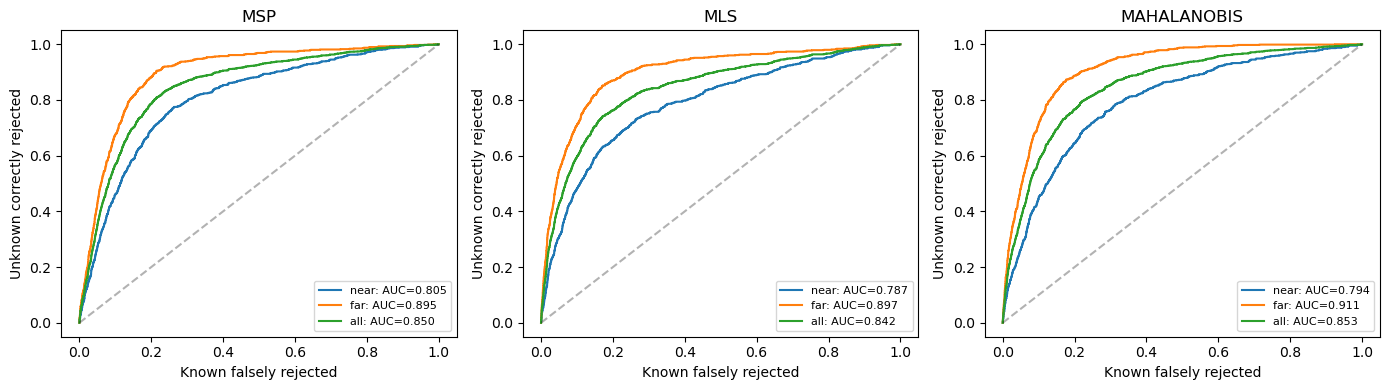

Files already downloaded and verified
Files already downloaded and verified


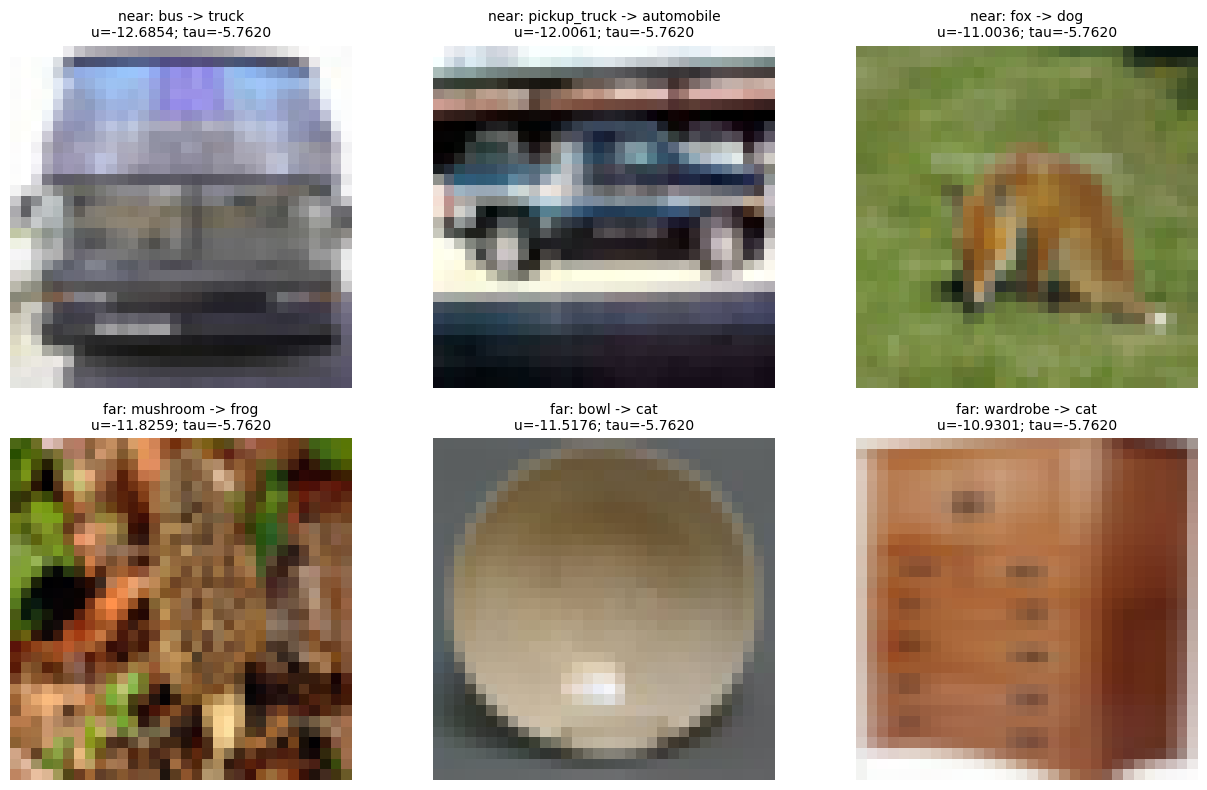

,group,index,unknown_class,predicted_known_class,score,threshold,selected_for_figure,semantic_interpretation
0,near,5201,bus,truck,-12.685422,-5.762002,True,Review image: plausible confusion or surprisin...
1,near,7658,pickup_truck,automobile,-12.006089,-5.762002,True,Review image: plausible confusion or surprisin...
2,near,959,fox,dog,-11.003612,-5.762002,True,Review image: plausible confusion or surprisin...
3,far,1196,mushroom,frog,-11.825851,-5.762002,True,Review image: plausible confusion or surprisin...
4,far,4252,bowl,cat,-11.517572,-5.762002,True,Review image: plausible confusion or surprisin...
5,far,9734,wardrobe,cat,-10.930078,-5.762002,True,Review image: plausible confusion or surprisin...


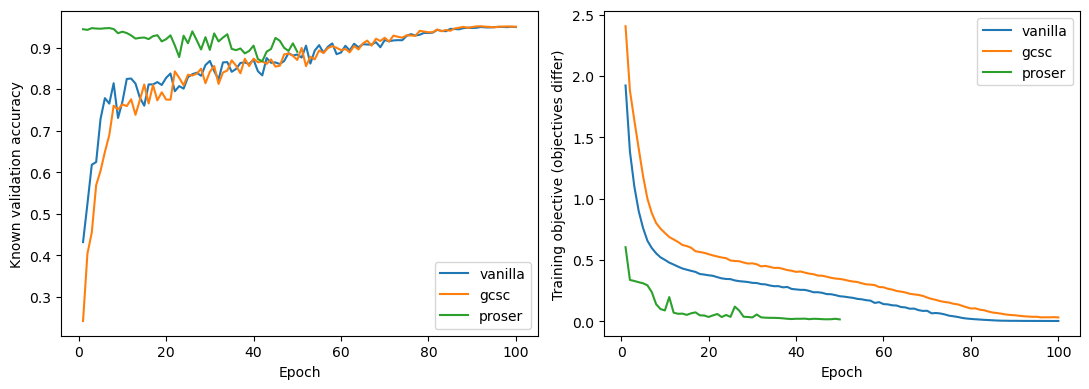

Evidence saved to d:\LUMS GAMING\6. 2026 Fall\CS 6304\Programming Assignments\PA1\Task 4\task4\results\evaluation Complete the visual interpretation and report prose using your observed results.


In [1]:
# Load extraction definitions, but skip its parameters and phase-dispatch cell.
from pathlib import Path
import json
base=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'extract_outputs.ipynb').exists()),None)
if base is None:
    base=Path.cwd()/'Task 4/task4'
    if not base.exists():base=Path.cwd()/'task4'
obj=json.loads((base/'extract_outputs.ipynb').read_text(encoding='utf-8'))
for i,c in enumerate(obj['cells']):
    if c['cell_type']=='code' and not set(c.get('metadata',{}).get('tags',[]))&{'parameters','dispatch'}:
        exec(compile(''.join(c['source']),str(base/'extract_outputs.ipynb')+f':cell-{i+1}','exec'),globals())
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
use('evaluation/metrics.ipynb');use('evaluation/failure_analysis.ipynb')
lock=verify_lock()
record=read_json(ROOT/'results/unknown_extraction.json')
if record['protocol_lock_sha256']!=sha(ROOT/'results/protocol_lock.json'):raise ValueError('Unknown extraction belongs to a different protocol.')
for path,digest in record['files'].items():
    if sha(ROOT/path)!=digest:raise ValueError('Unknown cache changed.')
output=ROOT/'results/evaluation';output.mkdir(exist_ok=True)
thresholds=read_json(ROOT/'results/calibration/thresholds.json')
bias=read_json(ROOT/'results/calibration/placeholder.json')['bias']
with np.load(ROOT/'results/calibration/mahalanobis.npz',allow_pickle=False) as a:
    means,variance=a['means'],a['variance']
score_map={};rows=[];example_rows=[]
for method in METHODS:
    score_map[method]={}
    for part in ['validation','test','near','far']:
        a=read_cache(method,part)
        reference=read_cache('vanilla',part)
        if not np.array_equal(a['indices'],reference['indices']) or not np.array_equal(a['labels'],reference['labels']):raise ValueError('Models must receive identical examples in identical order.')
        score_map[method][part]=all_scores(method,a,means,variance,bias)
        for name,u in score_map[method][part].items():
            tau=thresholds[f'{method}/{name}']['threshold']
            example_rows.append(pd.DataFrame(dict(model=method,score_name=name,partition=part,index=a['indices'],label=a['labels'],prediction=a['logits'].argmax(1),unknownness=u,threshold=tau,accepted=u<=tau)))
    test=read_cache(method,'test')
    csa=float(np.mean(test['logits'].argmax(1)==test['labels']))
    for name in score_map[method]['test']:
        calibration=thresholds[f'{method}/{name}'];tau=calibration['threshold']
        rows.append(dict(model=method,score=name,csa=csa,known_validation_acceptance=calibration['known_validation_acceptance'],**osr_metrics(score_map[method]['test'][name],score_map[method]['near'][name],score_map[method]['far'][name],tau)))
metrics=pd.DataFrame(rows)
table1=metrics[metrics.model=='vanilla'].set_index('score').loc[['msp','mls','energy','mahalanobis']].reset_index()
table2=metrics[(metrics.score=='mls')|((metrics.model=='proser')&(metrics.score=='placeholder'))].reset_index(drop=True)
table1.to_csv(output/'table1_vanilla_scores.csv',index=False);table2.to_csv(output/'table2_model_comparison.csv',index=False)
pd.concat(example_rows,ignore_index=True).to_csv(output/'per_example_scores.csv',index=False)
display(table1);display(table2)
print('Metrics are fractions (0..1), except raw thresholds. fpr95val is unknown acceptance, not ROC-interpolated FPR.')
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,name in zip(axes,['msp','mls','mahalanobis']):
    known=score_map['vanilla']['test'][name]
    for group in ['near','far','all']:
        unknown=np.concatenate([score_map['vanilla']['near'][name],score_map['vanilla']['far'][name]]) if group=='all' else score_map['vanilla'][group][name]
        labels=np.r_[np.zeros(len(known)),np.ones(len(unknown))];values=np.r_[known,unknown]
        fpr,tpr,_=roc_curve(labels,values)
        ax.plot(fpr,tpr,label=f'{group}: AUC={roc_auc_score(labels,values):.3f}')
    ax.plot([0,1],[0,1],'k--',alpha=.3);ax.set(title=name.upper(),xlabel='Known falsely rejected',ylabel='Unknown correctly rejected');ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(output/'vanilla_roc.png',dpi=180);plt.show()
# Rankings and decision disagreements support research question 2.
for part in ['test','near','far']:
    scores=pd.DataFrame(score_map['vanilla'][part])
    scores.corr(method='spearman').to_csv(output/f'score_rank_correlations_{part}.csv')
    decisions=pd.DataFrame({k:v<=thresholds[f'vanilla/{k}']['threshold'] for k,v in score_map['vanilla'][part].items()})
    pd.DataFrame({a:{b:float(np.mean(decisions[a]!=decisions[b])) for b in decisions} for a in decisions}).to_csv(output/f'score_decision_disagreements_{part}.csv')
    disagree=decisions.nunique(axis=1)>1
    examples=scores.loc[disagree].copy();cache=read_cache('vanilla',part)
    examples.insert(0,'index',cache['indices'][disagree]);examples.insert(1,'label',cache['labels'][disagree]);examples.to_csv(output/f'score_disagreement_examples_{part}.csv',index=False)
# Per-class rejection and the known classes that absorb accepted unknowns.
ds,groups=unknown_data();class_rows=[];absorption=[]
known_names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
for method in METHODS:
    for group in ['near','far']:
        a=read_cache(method,group)
        for name,u in score_map[method][group].items():
            accepted=u<=thresholds[f'{method}/{name}']['threshold']
            pred=a['logits'].argmax(1)
            for c in np.unique(a['labels']):
                select=a['labels']==c
                class_rows.append(dict(model=method,score=name,group=group,unknown_class=ds.classes[int(c)],n=int(select.sum()),acceptance=float(accepted[select].mean()),rejection=float((~accepted[select]).mean())))
                for k in range(10):
                    absorption.append(dict(model=method,score=name,group=group,unknown_class=ds.classes[int(c)],predicted_known_class=known_names[k],accepted_count=int(np.sum(select&accepted&(pred==k)))))
pd.DataFrame(class_rows).to_csv(output/'per_unknown_class.csv',index=False)
pd.DataFrame(absorption).to_csv(output/'unknown_label_absorption.csv',index=False)
display(failure_analysis(score_map,thresholds,output))
# Training curves use saved history; no training is triggered.
fig,axes=plt.subplots(1,2,figsize=(11,4))
for method in METHODS:
    h=pd.DataFrame(read_json(ROOT/'results'/method/'history.json'))
    axes[0].plot(h.epoch,h.validation_accuracy,label=method)
    axes[1].plot(h.epoch,h.train_loss,label=method)
axes[0].set(xlabel='Epoch',ylabel='Known validation accuracy');axes[1].set(xlabel='Epoch',ylabel='Training objective (objectives differ)')
for ax in axes:ax.legend()
fig.tight_layout();fig.savefig(output/'training_curves.png',dpi=180);plt.show()
# Describe measured changes without inventing an explanation from the numbers alone.
base_row=table2[(table2.model=='vanilla')&(table2.score=='mls')].iloc[0]
comparisons=[]
for _,row in table2.iterrows():
    comparisons.append(dict(model=row.model,score=row.score,**{f'delta_{key}':float(row[key]-base_row[key]) for key in ['csa','auroc_near','auroc_far','auroc_all','rejection_near','rejection_far']}))
pd.DataFrame(comparisons).to_csv(output/'changes_vs_vanilla_mls.csv',index=False)
report=output/'report.md'
if not report.exists():
    lines=['# Task 4: report to complete after inspecting outputs','', '## Measured changes relative to Vanilla MLS','']
    for r in comparisons:lines.append(f"- {r['model']} / {r['score']}: CSA {100*r['delta_csa']:+.2f} percentage points; near AUROC {r['delta_auroc_near']:+.4f}; far AUROC {r['delta_auroc_far']:+.4f}; near rejection {100*r['delta_rejection_near']:+.2f} points; far rejection {100*r['delta_rejection_far']:+.2f} points.")
    lines+=['','## Interpretation prompts','', '1. Use per_unknown_class.csv and unknown_label_absorption.csv to identify the most frequently accepted classes and absorbing known labels. Inspect failure_examples.png and complete failure_interpretation.md; distinguish plausible semantic confusions from surprising visual failures.', '', '2. Compare score_rank_correlations_*.csv, score_decision_disagreements_*.csv and individual disagreement examples. MSP measures relative confidence; MLS absolute maximum logit; Energy aggregate logit evidence; Mahalanobis feature distance. Connect actual disagreements to these mechanisms.', '', '3. Use the GCSC MLS row to determine whether RandAugment improved CSA, near OSR, far OSR, both, or neither. Do not assume greater CSA guarantees better rejection.', '', '4. Contrast PROSER MLS and placeholder rows with both baselines. Its two losses encourage a dummy alternative after excluding the true class and assign mixed inter-class features to unknown. Discuss whether observed rejection gains cost CSA, and why interpolation cannot cover all unknown directions.', '', 'Distinguish AUROC ranking from the validation-calibrated operating point. The target is 95% known VALIDATION acceptance; actual known TEST acceptance can differ. Optional RPL was not implemented.']
    report.write_text('\n'.join(lines),encoding='utf-8')
write_json(output/'evaluation_manifest.json',dict(protocol_lock_sha256=sha(ROOT/'results/protocol_lock.json'),unknown_manifest_sha256=sha(ROOT/'results/unknown_extraction.json'),generated_tables=['table1_vanilla_scores.csv','table2_model_comparison.csv'],note='Generated from fixed caches; no model optimization or unknown-based calibration.'))
print('Evidence saved to',output,'Complete the visual interpretation and report prose using your observed results.')